# 竞赛主 Notebook（jingsai 环境，CPU 一次跑通）

## 记忆口诀
**params → prepare → trees → stack**（`lib_comp.py`）

## 数据
`./data/实验数据1.xlsx` + `./data/data_test1.xlsx`

## 实验（dinov3，非比赛）
`./tune/` · RNN / 节假日


In [7]:
import sys; sys.path.insert(0, '.')
import pandas as pd
from lib_comp import load_params, prepare, train_trees, compare, stack_v1, mape, TIME, TARGET

params = load_params()
TREES = params['trees']


In [8]:
# [B] 洗 + 拼接
df_hist, df_test, df_all = prepare(save_hist=True)
print(len(df_hist), len(df_test))


c:\Users\zhich\OneDrive\Desktop\github\竞赛\202608调度\comp\.\lib_clean.py:37: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  return df.infer_objects(copy=False).interpolate('time').ffill().bfill().reset_index(names=TIME)
c:\Users\zhich\OneDrive\Desktop\github\竞赛\202608调度\comp\.\lib_clean.py:37: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  return df.infer_objects(copy=False).interpolate('time').ffill().bfill().reset_index(names=TIME)


116734 2880


In [9]:
# [A] debug 树（7 维原始特征）
dbg = train_trees(df_all, params['val_start'], TREES, full=False)
compare({k: {'y': dbg['yva'], 'p': v} for k, v in dbg['res_val'].items()})


Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[7]	valid_0's l2: 6.23993e+06
model     mape%
  xgb 10.187441
  cat 10.293964
  lgb 10.322214


,model,mape%
0,lgb,10.322214
1,xgb,10.187441
2,cat,10.293964


In [10]:
# [C→A] 全特征树
pack = train_trees(df_all, params['val_start'], TREES, full=True)
compare({k: {'y': pack['yva'], 'p': v} for k, v in pack['res_val'].items()})
yva, dte = pack['yva'], pack['dte']
tree_test = pack['res_test']


Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[461]	valid_0's l2: 612386
model    mape%
  xgb 2.528222
  cat 2.574377
  lgb 2.622198


In [11]:
# stack（Ridge 融合三棵树）
pva1, pte1, _ = stack_v1(pack, alpha=params['stack_alpha'])
print(f'[stack] val mape={mape(yva, pva1)*100:.2f}%')
pd.DataFrame({TIME: dte, TARGET: pte1}).to_csv('final_trees.csv', index=False)


[stack] val mape=2.36%


## test 预测汇总与可视化


In [12]:
import matplotlib.pyplot as plt

pred_test = pd.DataFrame({TIME: dte})
for name in TREES:
    pred_test[name] = tree_test[name]
pred_test['stack'] = pte1
if TARGET in df_test.columns:
    pred_test = pred_test.merge(
        df_test[[TIME, TARGET]].assign(**{TIME: pd.to_datetime(df_test[TIME])}),
        on=TIME, how='left', suffixes=('', '_true'),
    )
    if f'{TARGET}_true' in pred_test.columns:
        pred_test[TARGET] = pred_test[f'{TARGET}_true']
        pred_test = pred_test.drop(columns=[f'{TARGET}_true'])
pred_test.to_csv('pred_test_all.csv', index=False)
pred_test.head()


,date,lgb,xgb,cat,stack,全口径发购
0,2025-05-01 00:00:00,17214.387872,17509.980469,17340.258940,17648.728189,17203.429776
1,2025-05-01 00:15:00,17238.524545,17563.242188,17317.284263,17690.074971,17519.120818
2,2025-05-01 00:30:00,17314.531595,17587.478516,17437.000511,17728.391272,17813.460610
3,2025-05-01 00:45:00,17664.558439,17860.330078,17823.286370,18018.069239,17611.146413
4,2025-05-01 01:00:00,17923.046836,17983.230469,17942.511480,18128.422099,17541.961531


  lgb      2.72%
  xgb      2.73%
  cat      2.54%
  stack    2.66%


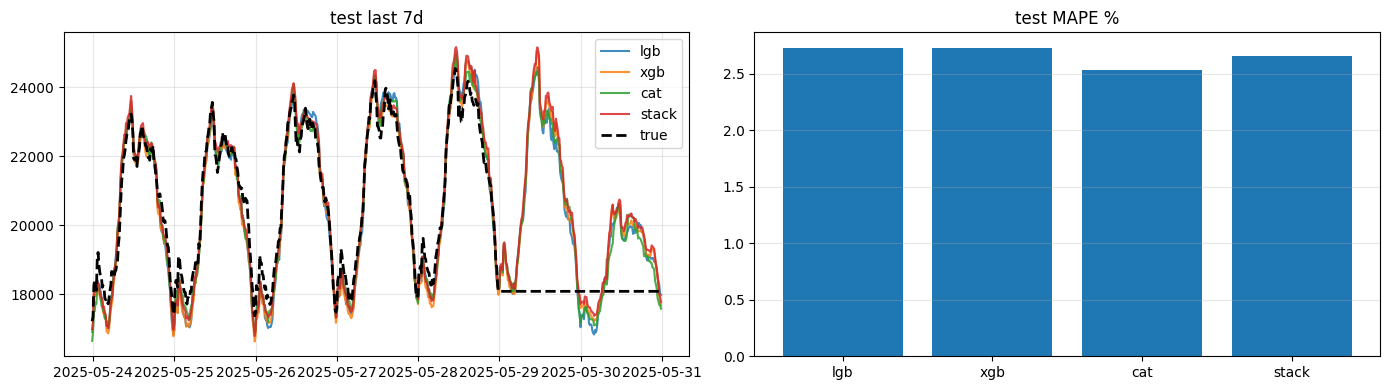

In [13]:
MODEL_COLS = list(TREES) + ['stack']
dte_plot = pd.to_datetime(dte)
mask = dte_plot >= dte_plot.max() - pd.Timedelta(days=7)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for col in MODEL_COLS:
    axes[0].plot(dte_plot[mask], pred_test.loc[mask, col], label=col, alpha=0.85)
if TARGET in pred_test.columns:
    axes[0].plot(dte_plot[mask], pred_test.loc[mask, TARGET], "k--", lw=2, label="true")
axes[0].set_title('test last 7d')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

if TARGET in pred_test.columns:
    yt = pred_test[TARGET].values
    mapes = {col: mape(yt, pred_test[col].values) * 100 for col in MODEL_COLS}
    axes[1].bar(mapes.keys(), mapes.values())
    axes[1].set_title('test MAPE %')
    axes[1].grid(True, axis="y", alpha=0.3)
    for col, v in mapes.items():
        print(f"  {col:8s} {v:.2f}%")
plt.tight_layout()
plt.show()
